A/B Testing in Digital Marketing:
The goal of this A/B test is to compare campaign types "Awareness" and "Conversion" to determine which one performs better on the metric of conversion rates. 

Ho: The 'Conversion' Campaign Type does not have a significantly higher conversion rate than the 'Awareness' Campaign Type.
Ha: The 'Conversion' Campaign Type has a significantly higher conversion rate than the 'Awareness' Campaign Type. 

In [11]:
import pandas as pd

In [12]:
# Import Data
df = pd.read_csv("digital_marketing_campaign_dataset.csv")

In [13]:
# check data types and missing values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [14]:
# 0 missing values in all columns
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [CustomerID, Age, Gender, Income, CampaignChannel, CampaignType, AdSpend, ClickThroughRate, ConversionRate, WebsiteVisits, PagesPerVisit, TimeOnSite, SocialShares, EmailOpens, EmailClicks, PreviousPurchases, LoyaltyPoints, AdvertisingPlatform, AdvertisingTool, Conversion]
Index: []


In [15]:
# Subset the two groups Awareness and Conversion. 
# Drop unnecessary columns. 
awareness_group = df[df["CampaignType"] == 'Awareness'].drop(columns=["AdvertisingPlatform", "AdvertisingTool"])
conversion_group = df[df["CampaignType"] == 'Conversion'].drop(columns=["AdvertisingPlatform", "AdvertisingTool"])
print(awareness_group.info())
print(conversion_group.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1988 entries, 0 to 7999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1988 non-null   int64  
 1   Age                1988 non-null   int64  
 2   Gender             1988 non-null   object 
 3   Income             1988 non-null   int64  
 4   CampaignChannel    1988 non-null   object 
 5   CampaignType       1988 non-null   object 
 6   AdSpend            1988 non-null   float64
 7   ClickThroughRate   1988 non-null   float64
 8   ConversionRate     1988 non-null   float64
 9   WebsiteVisits      1988 non-null   int64  
 10  PagesPerVisit      1988 non-null   float64
 11  TimeOnSite         1988 non-null   float64
 12  SocialShares       1988 non-null   int64  
 13  EmailOpens         1988 non-null   int64  
 14  EmailClicks        1988 non-null   int64  
 15  PreviousPurchases  1988 non-null   int64  
 16  LoyaltyPoints      1988 non-n

In [ ]:
print(awareness_group['conversion'])

In [16]:
#Check that each data point belongs exclusively to either 
# the 'Conversion' or 'Awareness' group
overlap = set(awareness_group.index).intersection(set(conversion_group.index))
print(f"Number of overlapping samples: {len(overlap)}")

if len(overlap) > 0:
    print("Warning: There are overlapping samples between the two groups!")

Number of overlapping samples: 0


In [17]:
# Calculate the mean of each group. 
awareness_mean = awareness_group['ConversionRate'].mean()
conversion_mean = conversion_group['ConversionRate'].mean()
print(f"Awareness Campaign Mean: {awareness_mean}")
print(f"Conversion Campaign Mean: {conversion_mean}")

Awareness Campaign Mean: 0.10437171910391599
Conversion Campaign Mean: 0.10485920903741773


In [18]:
# Find out is the distributions are normal. 
from scipy.stats import shapiro

# Perform Shapiro-Wilk test on Awareness group
awareness_stat, awareness_p = shapiro(awareness_group['ConversionRate'])
print(f"Awareness group - statistic: {awareness_stat}, P-value: {awareness_p}")

# Perform Shapiro-Wilk test on Conversion group
conversion_stat, conversion_p = shapiro(conversion_group['ConversionRate']) 
print(f"Conversion group - statistic: {conversion_stat}, P-value: {conversion_p}")

# Interpret the results for Awareness group
if awareness_p > 0.05:
    print("The Awareness Group distribution is likely a normal distribution")
else:
    print("The Awareness Group distribution is likely NOT a normal distribution")

# Interpret the results for Conversion group
if conversion_p > 0.05:
    print("The Conversion Group distribution is likely a normal distribution")
else:
    print("The Conversion Group distribution is likely NOT a normal distribution")


Awareness group - statistic: 0.9534923967166478, P-value: 1.1587335020303155e-24
Conversion group - statistic: 0.9534761564729226, P-value: 3.398116244508723e-25
The Awareness Group distribution is likely NOT a normal distribution
The Conversion Group distribution is likely NOT a normal distribution


In [23]:
# Perform Levene's test
stat, p_value = levene(awareness_group['ConversionRate'], conversion_group['ConversionRate'])

print(f"Levene's Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpret the result
if p_value > 0.05:
    print("The variances of the groups are equal.")
else:
    print("The variances of the groups are NOT equal.")


Levene's Statistic: 0.4077622462594529
P-value: 0.5231434831842393
The variances of the groups are equal.


In [19]:
# Both the Awareness Group and the Conversion group do NOT have a normal distribution. 
# So we cannot do a ttest. 
# We should use a Mann-Whitney U Test . 

from scipy.stats import mannwhitneyu

# Perform Mann-Whitney U Test. 
stat, p_value = mannwhitneyu(
    awareness_group['ConversionRate'], 
    conversion_group['ConversionRate'],
    alternative='greater'
)

print(f"Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpret the results
if p_value > 0.05:
    print("Fail to reject the null Hypothesis: The Conversion campaign does NOT have a significantly higher conversion rate than the Awareness Campaign")
else:
    print("Reject the null hypothesis: The Cvonversion campaign does have a significantly higher conversion rate than the Awareness campaign")

Statistic: 2053870.0
P-value: 0.6122631776129032
Fail to reject the null Hypothesis: The Conversion campaign does NOT have a significantly higher conversion rate than the Awareness Campaign


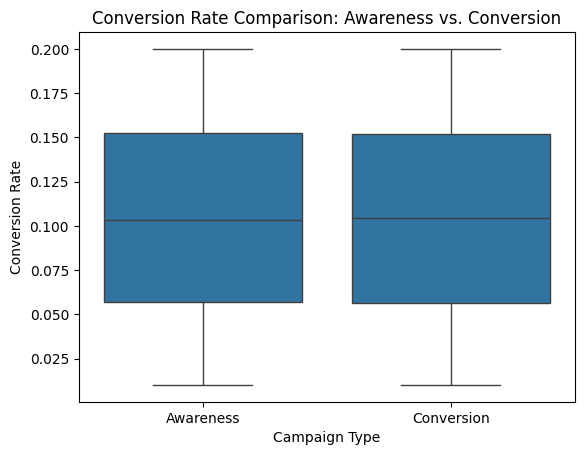

In [20]:
# Let's visualise the results. 

import seaborn as sns
import matplotlib.pyplot as plt

# Create a combined dataset for visualization
awareness_group['Group'] = 'Awareness'
conversion_group['Group'] = 'Conversion'
combined_data = pd.concat([awareness_group, conversion_group])

# Boxplot
sns.boxplot(x='Group', y='ConversionRate', data=combined_data)
plt.title('Conversion Rate Comparison: Awareness vs. Conversion')
plt.xlabel('Campaign Type')
plt.ylabel('Conversion Rate')
plt.show()
